Importing the modules

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sklearn.datasets.fetch_california_housing() is a function that loads the California housing dataset, which is a commonly used dataset for regression tasks.The target variable is the median house value, which we will be trying to predict using our machine learning model.

In [38]:
# housing = fetch_california_housing()
# df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
# df['Price'] = housing.target
# print(df.head())

Instead of considering the California housing dataset, we will be using a different dataset called "Bengaluru House Data" which contains information about house prices in Bengaluru, India.We will be using this dataset to build a machine learning model to predict house prices in Bengaluru.

In [39]:
df = pd.read_csv('D:/Product Projects/ml-internship/machine_learning_intership/datasets/Bengaluru_House_Data.csv', index_col=0)
print(df.head())


                       availability                  location       size  \
area_type                                                                  
Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
Plot  Area            Ready To Move          Chikka Tirupathi  4 Bedroom   
Built-up  Area        Ready To Move               Uttarahalli      3 BHK   
Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

                      society total_sqft  bath  balcony   price  
area_type                                                        
Super built-up  Area  Coomee        1056   2.0      1.0   39.07  
Plot  Area            Theanmp       2600   5.0      3.0  120.00  
Built-up  Area            NaN       1440   2.0      3.0   62.00  
Super built-up  Area  Soiewre       1521   3.0      1.0   95.00  
Super built-up  Area      NaN       1200   2.0      1.0   51.00  


In [40]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

(13320, 8)
<class 'pandas.DataFrame'>
Index: 13320 entries, Super built-up  Area to Super built-up  Area
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   availability  13320 non-null  str    
 1   location      13319 non-null  str    
 2   size          13304 non-null  str    
 3   society       7818 non-null   str    
 4   total_sqft    13320 non-null  str    
 5   bath          13247 non-null  float64
 6   balcony       12711 non-null  float64
 7   price         13320 non-null  float64
dtypes: float64(3), str(5)
memory usage: 936.6+ KB
None
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64
               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min 

In [41]:
#Dropping society columns as it is containing large number of null values and it is not useful for our analysis
df.drop(columns=['society'],inplace=True)

In [42]:
#converting the size column to bhk column by extracting the number of bedrooms from the size column ( 2 BEDROOM -> 2.00)
df['bhk'] = df['size'].str.extract(r'(\d+)').astype(float)
print(df['bhk'].unique())
print(df['bhk'].isnull().sum())
df.drop(columns=['size'],inplace=True)
print(df.isnull().sum())


[ 2.  4.  3.  6.  1.  8.  7.  5. 11.  9. nan 27. 10. 19. 16. 43. 14. 12.
 13. 18.]
16
availability      0
location          1
total_sqft        0
bath             73
balcony         609
price             0
bhk              16
dtype: int64


In [43]:
#converting the range of numbers a in the total_sqft column to a single number by taking the average of the range
def convert_total_sqft_to_num(value):
    try:
        if '-' in value:
            parts = value.split('-')
            if len(parts) == 2:
                return (float(parts[0]) + float(parts[1])) / 2
        else:
            return float(value)
    except:
        return None
df['total_sqft'] = df['total_sqft'].apply(convert_total_sqft_to_num)
print(df['total_sqft'].dtype)
print(df['total_sqft'].isnull().sum())

#dropping the nulls
df.dropna(inplace=True)

float64
46


In [44]:
#calculating the price per sqft
print(df['price'].describe())
print(df['bhk'].describe())
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']
print(df['price_per_sqft'].describe())

count    12668.000000
mean       105.952648
std        131.813137
min          8.000000
25%         49.015000
50%         70.000000
75%        115.000000
max       2912.000000
Name: price, dtype: float64
count    12668.000000
mean         2.736422
std          1.202643
min          1.000000
25%          2.000000
50%          3.000000
75%          3.000000
max         43.000000
Name: bhk, dtype: float64
count    1.266800e+04
mean     6.876277e+03
std      2.263354e+04
min      2.678298e+02
25%      4.242721e+03
50%      5.376344e+03
75%      7.142857e+03
max      2.300000e+06
Name: price_per_sqft, dtype: float64


In [45]:
#removing outliers based on price per sqft
def remove_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out
df = remove_outliers(df)
print(df.shape)

(9515, 8)


In [46]:
#adding location column for the features as location is a categorical variable and it is an important feature for predicting house prices
print(df['location'].nunique())
location_count = df['location'].value_counts()
print(location_count)
print(f"Location count less than 10:{(location_count<10).sum()}")


779
location
Whitefield         510
Sarjapur  Road     298
Electronic City    283
Kanakpura Road     191
Yelahanka          180
                  ... 
Virupakshapura       1
Whitefield,          1
Yarandahalli         1
frazertown           1
manyata park         1
Name: count, Length: 779, dtype: int64
Location count less than 10:581


In [47]:
#Replacing rare locations with 'other'
rare_locations = location_count[location_count < 10].index
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)
print(f"Unique locations after grouping: {df['location'].nunique()}")

Unique locations after grouping: 199


In [48]:
#Hot encoding the categorical variable location
df = pd.get_dummies(df, columns=['location'], drop_first=True)
print(df.head())
print(df.shape)
print(df.columns[:10])



    availability  total_sqft  bath  balcony  price  bhk  price_per_sqft  \
0  Ready To Move      1672.0   3.0      2.0  150.0  3.0     8971.291866   
1  Ready To Move      1750.0   3.0      3.0  149.0  3.0     8514.285714   
2  Ready To Move      1750.0   3.0      2.0  150.0  3.0     8571.428571   
3         18-May      1250.0   2.0      3.0   44.0  3.0     3520.000000   
4  Ready To Move      1250.0   2.0      2.0   40.0  2.0     3200.000000   

   location_1st Phase JP Nagar  location_2nd Stage Nagarbhavi  \
0                        False                          False   
1                        False                          False   
2                        False                          False   
3                        False                          False   
4                        False                          False   

   location_5th Phase JP Nagar  ...  location_Vasanthapura  \
0                        False  ...                  False   
1                        False  ..

In [49]:
#feature selection
location_columns = [col for col in df.columns if col.startswith('location_')]
print(location_columns)
features = ['bhk','total_sqft','bath','balcony'] + location_columns
X = df[features]
y = df['price']
print(X.shape)

['location_1st Phase JP Nagar', 'location_2nd Stage Nagarbhavi', 'location_5th Phase JP Nagar', 'location_6th Phase JP Nagar', 'location_7th Phase JP Nagar', 'location_8th Phase JP Nagar', 'location_9th Phase JP Nagar', 'location_Abbigere', 'location_Akshaya Nagar', 'location_Ambalipura', 'location_Ambedkar Nagar', 'location_Amruthahalli', 'location_Anandapura', 'location_Ananth Nagar', 'location_Anekal', 'location_Anjanapura', 'location_Ardendale', 'location_Arekere', 'location_Attibele', 'location_BTM 2nd Stage', 'location_BTM Layout', 'location_Babusapalaya', 'location_Balagere', 'location_Banashankari', 'location_Banashankari Stage II', 'location_Banashankari Stage III', 'location_Banashankari Stage V', 'location_Banaswadi', 'location_Bannerghatta Road', 'location_Basavangudi', 'location_Basaveshwara Nagar', 'location_Battarahalli', 'location_Begur', 'location_Begur Road', 'location_Bellandur', 'location_Bhoganhalli', 'location_Billekahalli', 'location_Binny Pete', 'location_Bisuva

In [50]:
#splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(7612, 202)
(1903, 202)


In [51]:
#training the model using linear regression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
#predicting the house prices using the trained model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")
print("RMSE:", np.sqrt(mse))


Mean Squared Error: 4227.545022468306
R^2 Score: 0.651748147310952
RMSE: 65.01957414862316


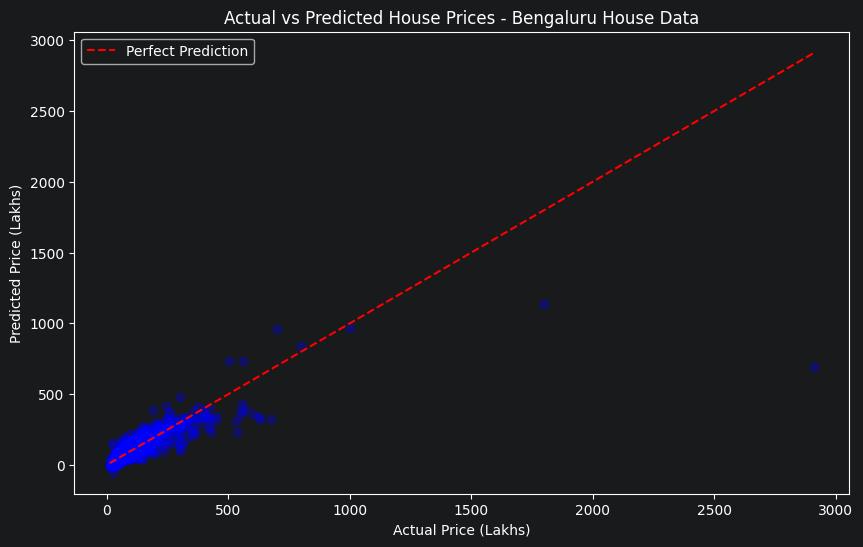

In [53]:
#plotting the model
plt.figure(figsize=(10, 6))
plt.scatter(y_test,y_pred,alpha=0.3,color='blue')
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted House Prices - Bengaluru House Data")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.legend()
plt.show()

In [55]:
#Saving the model
import joblib
joblib.dump(model, 'D:/Product Projects/ml-internship/machine_learning_intership/trained_models/house_price_prediction_model.pkl')
print('Model saved successfully!')


Model saved successfully!


In [59]:
import json
feature_names = list(X.columns)
with open('D:/Product Projects/ml-internship/machine_learning_intership/trained_models/house_price_features.json', 'w') as f:
    json.dump(feature_names, f)
    print("Feature names saved to feature_names.json")

Feature names saved to feature_names.json
